# Schema Normalization and Common Trajectory Schema

Notebook nay la buoc dau tien de chot schema chung `trips_clean` truoc khi khai pha toan bo du lieu 2021-2025.

Muc tieu:
- xem raw schema dai dien cua du lieu taxi tho
- xem schema chung sau khi chuan hoa thanh `trips_clean`
- doi chieu raw columns voi normalized columns
- audit cac truong raw bi bo va chi ra chung xuat hien o thang nao


## 1. Imports and Runtime Parameters

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

WORK_ROOT = Path.cwd().resolve()
if not (WORK_ROOT / "src").exists():
    WORK_ROOT = WORK_ROOT.parent
SRC_DIR = WORK_ROOT / "src"
REFERENCE_DIR = WORK_ROOT / "reference"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from test_read_minio_parquet import build_spark_session
from trajectory_utils import register_supporting_views, register_trajectory_view

SPARK_MASTER = "spark://spark-master:7077"
MINIO_ENDPOINT = "http://minio1:9000"
MINIO_ACCESS_KEY = "minioadmin"
MINIO_SECRET_KEY = "minioadmin"
BUCKET = "taxi-data"
YEARS = ["2021", "2022", "2023", "2024", "2025"]
RAW_SAMPLE_PATH = "s3a://taxi-data/2024/01/"
ZONE_LOOKUP_PATH = str(REFERENCE_DIR / "taxi_zone_lookup.csv")


## 2. Create Spark Session

In [2]:
try:
    spark.stop()
except Exception:
    pass

spark = build_spark_session(
    app_name="schema-normalization-story",
    endpoint=MINIO_ENDPOINT,
    access_key=MINIO_ACCESS_KEY,
    secret_key=MINIO_SECRET_KEY,
    master=SPARK_MASTER,
)
spark.sparkContext.setLogLevel("ERROR")
register_supporting_views(spark, ZONE_LOOKUP_PATH)
spark


:: loading settings :: url = jar:file:/usr/local/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/jovyan/.ivy2/cache
The jars for the packages stored in: /home/jovyan/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
software.amazon.awssdk#bundle added as a dependency
org.apache.spark#spark-avro_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-9d7af150-2672-4bb2-b33d-960b69376db2;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
	found org.apache.spark#spark-avro_2.13;4.0.1 in central
	found org.scala-lang.modules#scala-parallel-collections_2.13;1.2.0 in central
	found org.tukaani#xz;1.10 in central
:: resolution report :: resolve 381ms :: artifacts dl 4ms
	:: modules in use:
	org.apache.hadoop#hadoop-aw

## 3. Raw schema on a representative month

In [3]:
raw_df = (
    spark.read.option("recursiveFileLookup", "true")
    .option("pathGlobFilter", "*.parquet")
    .parquet(RAW_SAMPLE_PATH)
)
raw_df.printSchema()
print("Raw column count:", len(raw_df.columns))
print("Raw row count:", raw_df.count())
raw_df.show(5, truncate=False)


SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.
                                                                                

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

Raw column count: 19


Raw row count: 2964624
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2       |2024-01-01 00:57:55 |2024-01-01 01:17:43  |1              |1.72         |1         |N                 |186         |79          |2           |17.7       |

## 4. Normalize into `trips_clean`

In [4]:
trips_clean = register_trajectory_view(spark, raw_df)
trips_clean.printSchema()
print("Normalized column count:", len(trips_clean.columns))
trips_clean.show(5, truncate=False)


root
 |-- vendor_name_norm: string (nullable = true)
 |-- payment_type_norm: string (nullable = true)
 |-- pickup_ts: timestamp (nullable = true)
 |-- dropoff_ts: timestamp (nullable = true)
 |-- trip_date: date (nullable = true)
 |-- trip_year: integer (nullable = true)
 |-- trip_month: integer (nullable = true)
 |-- origin_zone_id: integer (nullable = true)
 |-- destination_zone_id: integer (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amt: double (nullable = true)
 |-- surcharge: double (nullable = true)
 |-- tip_amt: double (nullable = true)
 |-- tolls_amt: double (nullable = true)
 |-- total_amt: double (nullable = true)
 |-- start_lon: double (nullable = true)
 |-- start_lat: double (nullable = true)
 |-- end_lon: double (nullable = true)
 |-- end_lat: double (nullable = true)
 |-- has_gps_coordinates: boolean (nullable = false)
 |-- trajectory_mode: string (nullable = false)
 |-- route_key: string (nullable 

In [ ]:
mapping_rows = [
    ("VendorID / vendor_name", "vendor_name_norm", "Vendor chuan hoa"),
    ("payment_type / Payment_Type", "payment_type_norm", "Payment type chuan hoa"),
    ("tpep_pickup_datetime / Trip_Pickup_DateTime", "pickup_ts", "Thoi gian pickup"),
    ("tpep_dropoff_datetime / Trip_Dropoff_DateTime", "dropoff_ts", "Thoi gian dropoff"),
    ("PULocationID", "origin_zone_id", "Zone bat dau"),
    ("DOLocationID", "destination_zone_id", "Zone ket thuc"),
    ("trip_distance / Trip_Distance", "trip_distance", "Quang duong"),
    ("fare_amount / Fare_Amt", "fare_amt", "Tien cuoc"),
    ("total_amount / Total_Amt", "total_amt", "Tong tien"),
    ("Start_Lon / Start_Lat / End_Lon / End_Lat", "start_lon/start_lat/end_lon/end_lat", "Toa do GPS neu co"),
    ("computed", "origin_zone_bucket", "Hash bucket cho layout benchmark"),
    ("computed", "route_key", "Khoa tuyen origin -> destination"),
]
spark.createDataFrame(mapping_rows, ["raw_source", "trips_clean_column", "meaning"]).show(truncate=False)


+---------------------------------------------+-----------------------------------+--------------------------------+
|raw_source                                   |trips_clean_column                 |meaning                         |
+---------------------------------------------+-----------------------------------+--------------------------------+
|VendorID / vendor_name                       |vendor_name_norm                   |Vendor chuan hoa                |
|payment_type / Payment_Type                  |payment_type_norm                  |Payment type chuan hoa          |
|tpep_pickup_datetime / Trip_Pickup_DateTime  |pickup_ts                          |Thoi gian pickup                |
|tpep_dropoff_datetime / Trip_Dropoff_DateTime|dropoff_ts                         |Thoi gian dropoff               |
|PULocationID                                 |origin_zone_id                     |Zone bat dau                    |
|DOLocationID                                 |destination_zone_

## 5. Schema inventory across 2021-2025

In [6]:
def list_month_prefixes(bucket, years):
    prefixes = []
    jvm = spark._jvm
    hconf = spark._jsc.hadoopConfiguration()
    for year in years:
        year_path = jvm.org.apache.hadoop.fs.Path(f"s3a://{bucket}/{year}")
        fs = year_path.getFileSystem(hconf)
        if not fs.exists(year_path):
            continue
        for status in fs.listStatus(year_path):
            if status.isDirectory():
                prefixes.append(f"{year}/{status.getPath().getName()}")
    return sorted(prefixes)


def detect_schema_family(columns):
    columns = set(columns)
    if "PULocationID" in columns or "tpep_pickup_datetime" in columns:
        return "modern_zone"
    if "Start_Lon" in columns or "Trip_Pickup_DateTime" in columns:
        return "legacy_gps"
    return "mixed_unknown"


month_prefixes = list_month_prefixes(BUCKET, YEARS)
print("Detected month prefixes:", len(month_prefixes))
month_prefixes[:12]


Detected month prefixes: 59


['2021/01',
 '2021/02',
 '2021/03',
 '2021/04',
 '2021/05',
 '2021/06',
 '2021/07',
 '2021/08',
 '2021/09',
 '2021/10',
 '2021/11',
 '2021/12']

In [7]:
schema_inventory = []
for month_prefix in month_prefixes:
    month_path = f"s3a://{BUCKET}/{month_prefix}"
    month_df = (
        spark.read.option("recursiveFileLookup", "true")
        .option("pathGlobFilter", "*.parquet")
        .parquet(month_path)
    )
    month_columns = month_df.columns
    schema_inventory.append(
        {
            "month_prefix": month_prefix,
            "schema_family": detect_schema_family(month_columns),
            "columns": set(month_columns),
        }
    )

spark.createDataFrame(
    [(row["month_prefix"], row["schema_family"], len(row["columns"])) for row in schema_inventory],
    ["month_prefix", "schema_family", "column_count"],
).show(100, truncate=False)


+------------+-------------+------------+
|month_prefix|schema_family|column_count|
+------------+-------------+------------+
|2021/01     |modern_zone  |19          |
|2021/02     |modern_zone  |19          |
|2021/03     |modern_zone  |19          |
|2021/04     |modern_zone  |19          |
|2021/05     |modern_zone  |19          |
|2021/06     |modern_zone  |19          |
|2021/07     |modern_zone  |19          |
|2021/08     |modern_zone  |19          |
|2021/09     |modern_zone  |19          |
|2021/10     |modern_zone  |19          |
|2021/11     |modern_zone  |19          |
|2021/12     |modern_zone  |19          |
|2022/01     |modern_zone  |19          |
|2022/02     |modern_zone  |19          |
|2022/03     |modern_zone  |19          |
|2022/04     |modern_zone  |19          |
|2022/05     |modern_zone  |19          |
|2022/06     |modern_zone  |19          |
|2022/07     |modern_zone  |19          |
|2022/08     |modern_zone  |19          |
|2022/09     |modern_zone  |19    

## 6. Audit raw columns that are kept vs dropped

In [8]:
used_raw_columns = {
    "vendor_name",
    "VendorID",
    "Payment_Type",
    "payment_type",
    "Trip_Pickup_DateTime",
    "tpep_pickup_datetime",
    "Trip_Dropoff_DateTime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "Passenger_Count",
    "passenger_count",
    "Trip_Distance",
    "trip_distance",
    "Fare_Amt",
    "fare_amount",
    "surcharge",
    "extra",
    "Tip_Amt",
    "tip_amount",
    "Tolls_Amt",
    "tolls_amount",
    "Total_Amt",
    "total_amount",
    "Start_Lon",
    "Start_Lat",
    "End_Lon",
    "End_Lat",
}

drop_reason_map = {
    "RatecodeID": "Not included in the common trajectory schema v1",
    "Rate_Code": "Not included in the common trajectory schema v1",
    "store_and_fwd_flag": "Operational flag not kept in trajectory analytics v1",
    "store_and_forward": "Operational flag not kept in trajectory analytics v1",
    "mta_tax": "Cost component omitted to keep the common schema compact",
    "improvement_surcharge": "Cost component omitted to keep the common schema compact",
    "congestion_surcharge": "Cost component omitted to keep the common schema compact",
    "Airport_fee": "Cost component omitted to keep the common schema compact",
    "airport_fee": "Cost component omitted to keep the common schema compact",
    "cbd_congestion_fee": "Cost component omitted to keep the common schema compact",
    "extra": "Merged into the normalized surcharge column",
    "surcharge": "Merged into the normalized surcharge column",
}

raw_columns_detected = sorted(set().union(*[row["columns"] for row in schema_inventory]))
dropped_raw_columns = sorted(set(raw_columns_detected) - used_raw_columns)

classification_rows = []
for column_name in raw_columns_detected:
    families = sorted({row["schema_family"] for row in schema_inventory if column_name in row["columns"]})
    if families == ["legacy_gps"]:
        schema_presence = "legacy_only"
    elif families == ["modern_zone"]:
        schema_presence = "modern_only"
    else:
        schema_presence = "shared_across_schemas"
    if column_name in dropped_raw_columns:
        final_classification = "dropped_after_normalization"
    else:
        final_classification = schema_presence
    classification_rows.append((column_name, schema_presence, final_classification))

spark.createDataFrame(
    classification_rows,
    ["raw_column", "schema_presence", "classification"],
).orderBy("classification", "raw_column").show(200, truncate=False)


+---------------------+---------------+---------------------------+
|raw_column           |schema_presence|classification             |
+---------------------+---------------+---------------------------+
|Airport_fee          |modern_only    |dropped_after_normalization|
|RatecodeID           |modern_only    |dropped_after_normalization|
|airport_fee          |modern_only    |dropped_after_normalization|
|cbd_congestion_fee   |modern_only    |dropped_after_normalization|
|congestion_surcharge |modern_only    |dropped_after_normalization|
|improvement_surcharge|modern_only    |dropped_after_normalization|
|mta_tax              |modern_only    |dropped_after_normalization|
|store_and_fwd_flag   |modern_only    |dropped_after_normalization|
|DOLocationID         |modern_only    |modern_only                |
|PULocationID         |modern_only    |modern_only                |
|VendorID             |modern_only    |modern_only                |
|extra                |modern_only    |modern_on

In [9]:
dropped_rows = []
for column_name in dropped_raw_columns:
    month_hits = sorted([row["month_prefix"] for row in schema_inventory if column_name in row["columns"]])
    family_hits = sorted({row["schema_family"] for row in schema_inventory if column_name in row["columns"]})
    dropped_rows.append(
        (
            column_name,
            drop_reason_map.get(column_name, "Not used in the common trajectory schema v1"),
            ", ".join(family_hits),
            ", ".join(month_hits),
        )
    )

dropped_columns_df = spark.createDataFrame(
    dropped_rows,
    ["raw_column", "reason_not_kept", "appears_in_schema_family", "appears_in_month_prefixes"],
)
dropped_columns_df.show(200, truncate=False)


+---------------------+--------------------------------------------------------+------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|raw_column           |reason_not_kept                                         |appears_in_schema_family|appears_in_month_prefixes                                                                                                                                                                                                                                          

## 7. Coverage of important normalized columns

,column_name,coverage_ratio
0,pickup_ts,1.0
1,origin_zone_id,1.0
2,destination_zone_id,1.0
3,trip_distance,1.0
4,total_amt,1.0
5,route_key,1.0
6,has_gps_coordinates,1.0


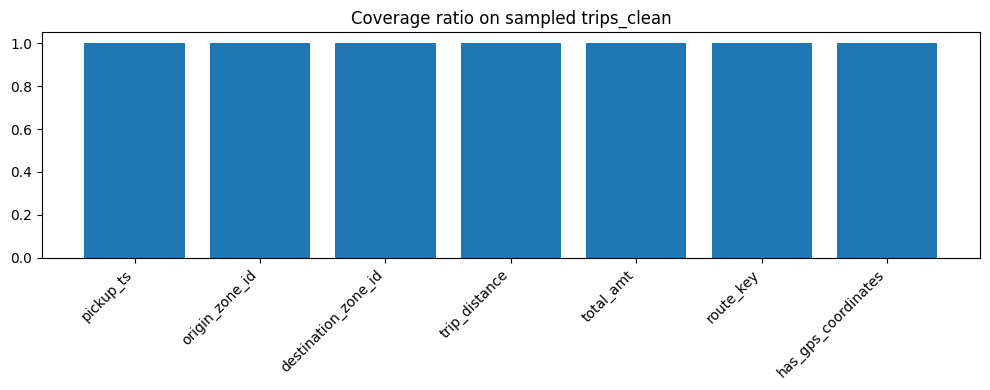

In [10]:
coverage_columns = [
    "pickup_ts",
    "origin_zone_id",
    "destination_zone_id",
    "trip_distance",
    "total_amt",
    "route_key",
    "has_gps_coordinates",
]

sample_df = trips_clean.sample(False, 0.01, seed=42).limit(100000)
sample_size = sample_df.count()
coverage_rows = []
for column_name in coverage_columns:
    non_null_count = sample_df.filter(F.col(column_name).isNotNull()).count()
    coverage_rows.append((column_name, non_null_count / sample_size))

coverage_pdf = spark.createDataFrame(coverage_rows, ["column_name", "coverage_ratio"]).toPandas()
coverage_pdf = coverage_pdf.sort_values("coverage_ratio", ascending=False)
display(coverage_pdf)

plt.figure(figsize=(10, 4))
plt.bar(coverage_pdf["column_name"], coverage_pdf["coverage_ratio"])
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.title("Coverage ratio on sampled trips_clean")
plt.tight_layout()
plt.show()
